In [1]:
using JLD2, TensorKit, LaTeXStrings, CairoMakie

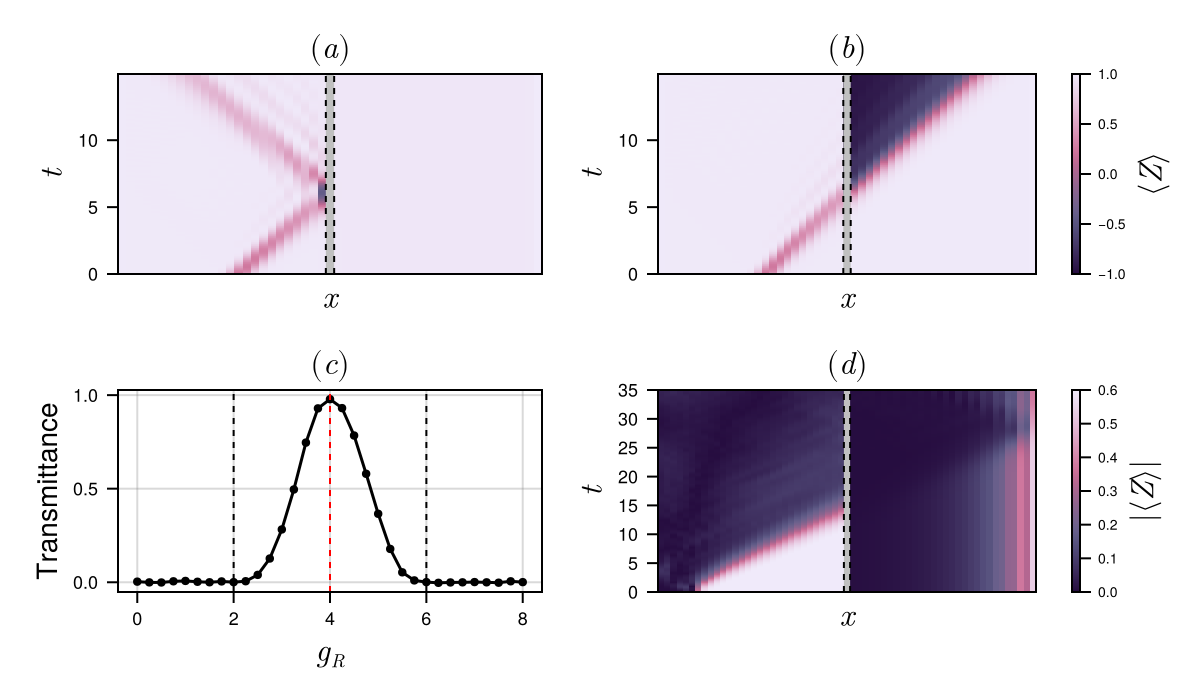

In [2]:
# ---------- load the data ----------
δt = 0.05
step = 600
L = 61


# reflection panel (a)
xs_a, ts_a, zs_a = load_object("data/Ising_gR_2.jld2")

# dual panel (b)
xs_b, ts_b, zs_b = load_object("data/Ising_gR_4.jld2")

# Transmission rate (c)
(g2_list, transmittance) = load_object("data/Transmittance.jld2")

# long time SPT–FM panel (d)
Xs_d, Ts_d, Zs_d = load_object("data/haldane_long.jld2")

# ---------- helper: gray interface slab + dashed lines ----------
function add_interface!(ax; x1, x2, ylow, yhigh)
    # slab
    poly!(ax,
        Point2f[(x1, ylow), (x2, ylow), (x2, yhigh), (x1, yhigh)];
        color = (:silver, 1.0),
        strokecolor = :transparent,
    )
    # dashed guide lines
    vlines!(ax, [x1, x2];
        color = :black,
        linestyle = :dash,
        linewidth = 1,
    )
    return nothing
end

# ---------- figure & layout ----------
fig = Figure(size = (600, 350), fontsize = 9)

# We'll make (1,2) and (2,2) nested grids so we can attach colorbars there
g12 = fig[1, 2] = GridLayout()
g22 = fig[2, 2] = GridLayout()

# ---------- (a) Reflection, NO colorbar ----------
ax_a = Axis(fig[1, 1];
    title = latexstring("(a)"),
    xlabel = latexstring("x"),
    ylabel = latexstring("t"),
    xticklabelsvisible = false,
    xticksvisible = false,
    yticks = [0, 5, 10, 15],
    limits = (nothing, nothing, 0.0, 14.95),  # (xlow,xhigh,ylow,yhigh)
)

hm_a = heatmap!(ax_a,
    xs_a,
    ts_a .- δt,
    permutedims(zs_a);
    colormap = :acton,
    colorrange = (-1, 1),
)

add_interface!(ax_a; x1 = 25.5, x2 = 26.5, ylow = 0.0, yhigh = 14.95)

# ---------- (b) Dual, WITH colorbar ----------
ax_b = Axis(g12[1, 1];
    title = latexstring("(b)"),
    xlabel = latexstring("x"),
    ylabel = latexstring("t"),
    xticklabelsvisible = false,
    xticksvisible = false,
    yticks = [0, 5, 10, 15],
    limits = (nothing, nothing, 0.0, 14.95),
)

hm_b = heatmap!(ax_b,
    xs_b,
    ts_b .- δt,
    permutedims(zs_b);
    colormap = :acton,
    colorrange = (-1, 1),
)

add_interface!(ax_b; x1 = 25.5, x2 = 26.5, ylow = 0.0, yhigh = 14.95)

cb_b = Colorbar(g12[1, 2], hm_b;
    width = 4,              # make it skinny
    ticklabelsize = 7,
    label=latexstring("⟨Z⟩"),
    labelsize = 16
)

# ---------- (c) Transmittance plot ----------
ax_c = Axis(fig[2, 1];
    title = latexstring("(c)"),
    xlabel = latexstring("g_R"),
    ylabel = "Transmittance",
)

lines!(ax_c, g2_list, transmittance;
    color = :black,
    linewidth = 1.5,
)

scatter!(ax_c, g2_list, transmittance;
    color = :black,
    markersize = 6,
)

# dashed vlines at g_R = 2, 4, 6
vlines!(ax_c, [2, 6];
    color = :black,
    linestyle = :dash,
    linewidth = 1,
)
vlines!(ax_c, [4];
    color = :red,
    linestyle = :dash,
    linewidth = 1,
)

# light grid like your Plots.jl version
ax_c.xgridvisible = true
ax_c.ygridvisible = true
ax_c.xgridcolor = (:gray, 0.3)
ax_c.ygridcolor = (:gray, 0.3)

# ---------- (d) Long-time, WITH colorbar ----------
ax_d = Axis(g22[1, 1];
    title = latexstring("(d)"),
    xlabel = latexstring("x"),
    ylabel = latexstring("t"),
    xticklabelsvisible = false,
    xticksvisible = false,
    limits = (nothing, nothing, 0.0, 35.0),
    xreversed = true,   # like xflip=true
)

hm_d = heatmap!(ax_d,
    Xs_d,
    Ts_d .+ δt,
    permutedims(abs.(Zs_d));
    colormap = :acton,
    colorrange = (0, 0.6),
)


add_interface!(ax_d; x1 = 30.5, x2 = 31.5, ylow = 0.0, yhigh = 35.0)

cb_d = Colorbar(g22[1, 2], hm_d;
    width = 4,
    ticklabelsize = 7,
    label=latexstring("|⟨Z⟩|"),
    labelsize = 16
)

# ---------- cosmetics ----------
ax_a.titlesize = 16
ax_b.titlesize = 16
ax_c.titlesize = 16
ax_d.titlesize = 16

ax_a.xlabelsize = 16
ax_a.ylabelsize = 16
ax_b.xlabelsize = 16
ax_b.ylabelsize = 16
ax_c.xlabelsize = 16
ax_c.ylabelsize = 14
ax_d.xlabelsize = 16
ax_d.ylabelsize = 16

# ---------- export ----------
# save("fig_transmission_makie.pdf", fig)
fig

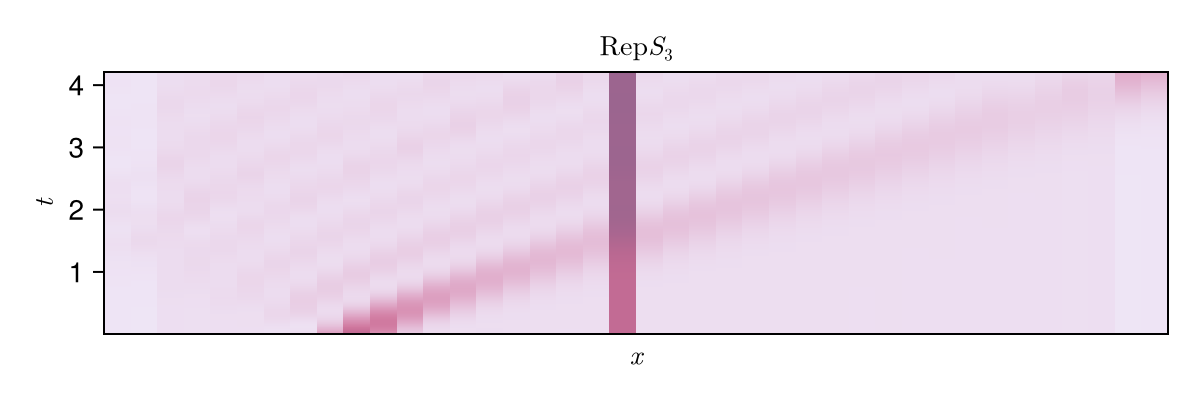

In [3]:
L_S3 = 40
Xs_list,Zs_list,_,_ = load_object("data/RepS3.jld2")
δt = 0.007
f = Figure(size=(600,200))
ax = Axis(f[1,1];
    title = latexstring(L"\mathrm{Rep} S_3"),
    xlabel = latexstring("x"),
    ylabel = latexstring("t"),
    xticklabelsvisible = false,
    xticksvisible = false,
)

hm_a = heatmap!(ax,
    1:L_S3,
    δt*collect(1:601),
    permutedims(Zs_list);
    colormap = :acton,
    colorrange = (-1, 1),
)
f